# Topic 1: Regression

# Correlation: fires and firefighters

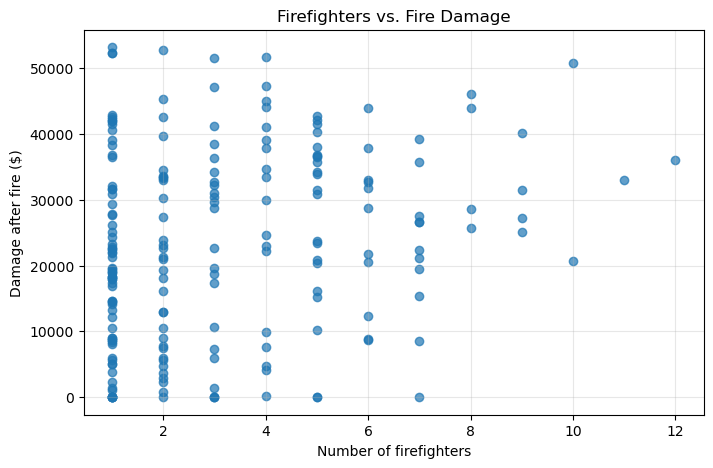

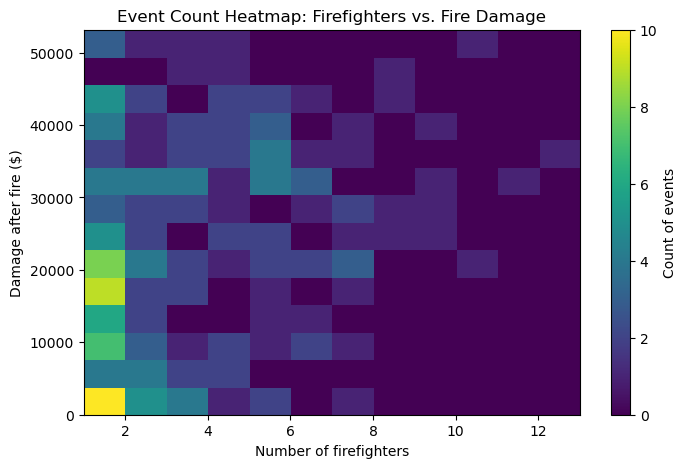

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 200
fire_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
firefighters = np.round(1 + 3 * fire_severity + rng.normal(0, 3, n)).astype(int)
firefighters = np.clip(firefighters, 1, None)

damage = 2000 + 50000 * fire_severity - 1000 * firefighters + rng.normal(0, 6000, n)
damage = np.clip(damage, 0, None)

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(firefighters, damage, alpha=0.7)
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Firefighters vs. Fire Damage")
plt.grid(True, alpha=0.3)
plt.show()

# Heatmap: counts of events in each firefighter x damage cell
x_bins = np.arange(firefighters.min(), firefighters.max() + 2)  # integer firefighter counts
y_bins = np.linspace(0, damage.max(), 15)  # damage bins

counts, xedges, yedges = np.histogram2d(firefighters, damage, bins=[x_bins, y_bins])

plt.figure(figsize=(8, 5))
plt.imshow(
    counts.T,
    origin="lower",
    aspect="auto",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="viridis"
)
plt.colorbar(label="Count of events")
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Event Count Heatmap: Firefighters vs. Fire Damage")
plt.show()

# What is a likely confounder?  (Don't type yet: first think about it.)

# Causation: fires and firefighters

=== Regression 1: Y_damage vs X_firefighters ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     10.81
Date:                Mon, 18 May 2026   Prob (F-statistic):            0.00120
Time:                        11:55:48   Log-Likelihood:                -2193.3
No. Observations:                 200   AIC:                             4391.
Df Residuals:                     198   BIC:                             4397.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

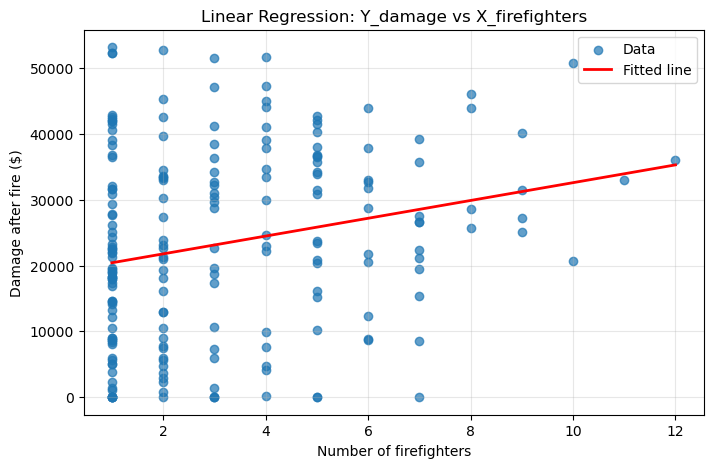


=== Regression 2: Y_damage vs X_firefighters and Z_severity ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     508.9
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.53e-78
Time:                        11:55:48   Log-Likelihood:                -2016.7
No. Observations:                 200   AIC:                             4039.
Df Residuals:                     197   BIC:                             4049.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 200
Z_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
X_firefighters = np.round(1 + 3 * Z_severity + rng.normal(0, 3, n)).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

# Z_severity up by one:
# Increase Y_damage by 50,000
# Increase firefighters by 3, which decreases Y_damage by 3,000
# So increase of firefighters by 3 should increased damage by 47,000 or about 16,000 per firefighter
# But Y_damage has stddev / error that doesn't come from Z_severity and so does X_firefighters

Y_damage = 2000 + 50000 * Z_severity - 1000 * X_firefighters + rng.normal(0, 6000, n)
Y_damage = np.clip(Y_damage, 0, None)

# ----------------------------
# 1) Simple linear regression:
#    Y_damage vs X_firefighters
# ----------------------------
df_simple = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters
})

X_simple = sm.add_constant(df_simple["X_firefighters"])
model_simple = sm.OLS(df_simple["Y_damage"], X_simple).fit()

print("=== Regression 1: Y_damage vs X_firefighters ===")
print(model_simple.summary())

# Plot data and fitted line
x_grid = np.linspace(df_simple["X_firefighters"].min(), df_simple["X_firefighters"].max(), 200)
X_grid = sm.add_constant(pd.Series(x_grid, name="X_firefighters"))
y_hat = model_simple.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(df_simple["X_firefighters"], df_simple["Y_damage"], alpha=0.7, label="Data")
plt.plot(x_grid, y_hat, color="red", linewidth=2, label="Fitted line")
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Linear Regression: Y_damage vs X_firefighters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 2) Multiple linear regression:
#    Y_damage vs X_firefighters and Z_severity
# ----------------------------
df_multi = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity
})

X_multi = sm.add_constant(df_multi[["X_firefighters", "Z_severity"]])
model_multi = sm.OLS(df_multi["Y_damage"], X_multi).fit()

print("\n=== Regression 2: Y_damage vs X_firefighters and Z_severity ===")
print(model_multi.summary())

# Random number of firefighters

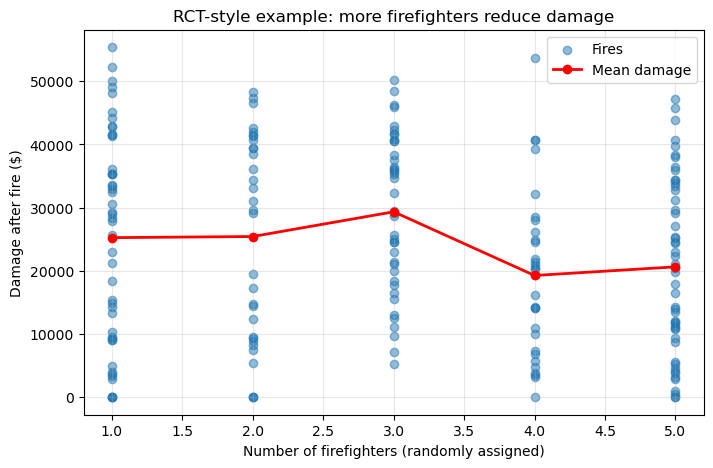

=== Regression 1: Y_damage vs X_firefighters ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.272
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0401
Time:                        09:35:03   Log-Likelihood:                -2202.3
No. Observations:                 200   AIC:                             4409.
Df Residuals:                     198   BIC:                             4415.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reproducible synthetic "RCT" example
rng = np.random.default_rng(42)

n = 200

# Fire severity exists, but is NOT used to assign firefighters
Z_severity = rng.uniform(0, 1, n)

# Random assignment: 1 through 5 firefighters, independent of severity
X_firefighters = rng.integers(1, 6, size=n)

# Outcome: more firefighters reduce damage
Y_damage = 2000 + 50000 * Z_severity - 1000 * X_firefighters + rng.normal(0, 6000, n)
Y_damage = np.clip(Y_damage, 0, None)

df = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity
})

# Plot: scatter + mean damage by firefighter count
plt.figure(figsize=(8, 5))
plt.scatter(df["X_firefighters"], df["Y_damage"], alpha=0.5, label="Fires")

means = df.groupby("X_firefighters")["Y_damage"].mean()
plt.plot(means.index, means.values, color="red", marker="o", linewidth=2, label="Mean damage")

plt.xlabel("Number of firefighters (randomly assigned)")
plt.ylabel("Damage after fire ($)")
plt.title("RCT-style example: more firefighters reduce damage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Regression 1: damage vs firefighters
X_simple = sm.add_constant(df["X_firefighters"])
model_simple = sm.OLS(df["Y_damage"], X_simple).fit()

print("=== Regression 1: Y_damage vs X_firefighters ===")
print(model_simple.summary())

# Regression 2: damage vs firefighters and severity
X_multi = sm.add_constant(df[["X_firefighters", "Z_severity"]])
model_multi = sm.OLS(df["Y_damage"], X_multi).fit()

print("\n=== Regression 2: Y_damage vs X_firefighters and Z_severity ===")
print(model_multi.summary())

# Higher sample count

=== Regression 1: Y_damage vs X_firefighters ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     10.81
Date:                Mon, 18 May 2026   Prob (F-statistic):            0.00120
Time:                        11:59:56   Log-Likelihood:                -2193.3
No. Observations:                 200   AIC:                             4391.
Df Residuals:                     198   BIC:                             4397.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

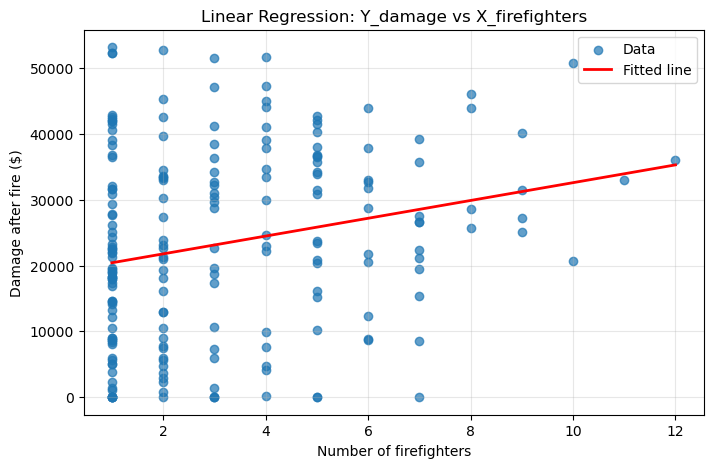


=== Regression 2: Y_damage vs X_firefighters and Z_severity ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     508.9
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.53e-78
Time:                        11:59:56   Log-Likelihood:                -2016.7
No. Observations:                 200   AIC:                             4039.
Df Residuals:                     197   BIC:                             4049.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 200
Z_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
X_firefighters = np.round(1 + 3 * Z_severity + rng.normal(0, 3, n)).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

Y_damage = 2000 + 50000 * Z_severity - 1000 * X_firefighters + rng.normal(0, 6000, n)
Y_damage = np.clip(Y_damage, 0, None)

# ----------------------------
# 1) Simple linear regression:
#    Y_damage vs X_firefighters
# ----------------------------
df_simple = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters
})

X_simple = sm.add_constant(df_simple["X_firefighters"])
model_simple = sm.OLS(df_simple["Y_damage"], X_simple).fit()

print("=== Regression 1: Y_damage vs X_firefighters ===")
print(model_simple.summary())

# Plot data and fitted line
x_grid = np.linspace(df_simple["X_firefighters"].min(), df_simple["X_firefighters"].max(), 200)
X_grid = sm.add_constant(pd.Series(x_grid, name="X_firefighters"))
y_hat = model_simple.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(df_simple["X_firefighters"], df_simple["Y_damage"], alpha=0.7, label="Data")
plt.plot(x_grid, y_hat, color="red", linewidth=2, label="Fitted line")
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Linear Regression: Y_damage vs X_firefighters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 2) Multiple linear regression:
#    Y_damage vs X_firefighters and Z_severity
# ----------------------------
df_multi = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity
})

X_multi = sm.add_constant(df_multi[["X_firefighters", "Z_severity"]])
model_multi = sm.OLS(df_multi["Y_damage"], X_multi).fit()

print("\n=== Regression 2: Y_damage vs X_firefighters and Z_severity ===")
print(model_multi.summary())

# Pareto distribution

=== Pareto distribution reminder ===
Scale parameter xm = 1.0
Shape parameter alpha = 0.8
Pareto(Type I) pdf:
  f(x) = alpha * xm^alpha / x^(alpha+1),  for x >= xm
  f(x) = 0,                               for x < xm
For alpha <= 1, the theoretical mean is infinite.



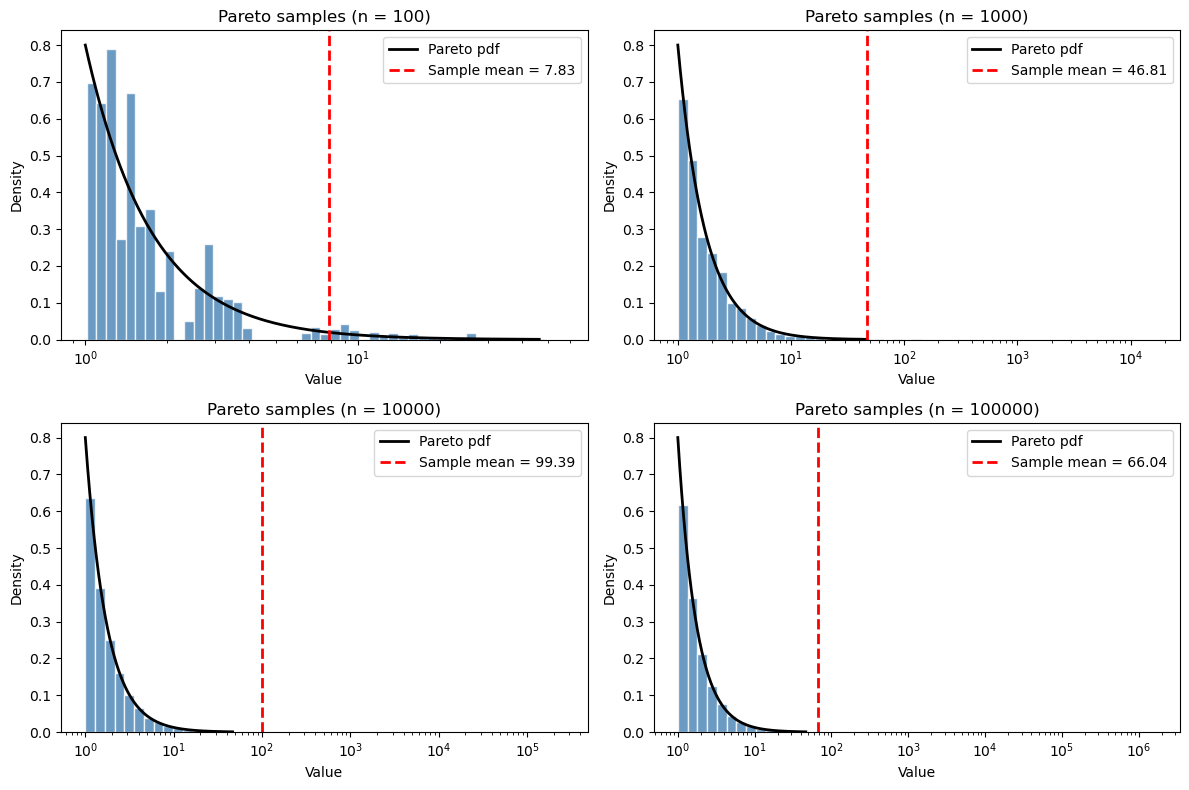

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def draw_pareto(n, alpha=2.5, xm=1.0, seed=None):
    """
    Draw n samples from a Pareto(Type I) distribution with scale xm and shape alpha.
    Uses NumPy's pareto, where if U ~ Pareto(alpha), then X = xm * (U + 1).
    """
    rng = np.random.default_rng(seed)
    return xm * (rng.pareto(alpha, size=n) + 1.0)

def pareto_pdf(x, alpha=2.5, xm=1.0):
    """
    Pareto(Type I) pdf:
        f(x) = alpha * xm^alpha / x^(alpha+1),  for x >= xm
        f(x) = 0,                                for x < xm
    """
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)
    mask = x >= xm
    pdf[mask] = alpha * (xm ** alpha) / (x[mask] ** (alpha + 1))
    return pdf

# Parameters
alpha = 0.8
xm = 1.0
sample_sizes = [100, 1000, 10000, 100000]

print("=== Pareto distribution reminder ===")
print(f"Scale parameter xm = {xm}")
print(f"Shape parameter alpha = {alpha}")
print("Pareto(Type I) pdf:")
print("  f(x) = alpha * xm^alpha / x^(alpha+1),  for x >= xm")
print("  f(x) = 0,                               for x < xm")
print("For alpha <= 1, the theoretical mean is infinite.")
print()

# Theoretical mean exists for alpha > 1:
# E[X] = alpha * xm / (alpha - 1)
theoretical_mean = alpha * xm / (alpha - 1) if alpha > 1 else np.inf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, n in zip(axes, sample_sizes):
    x = draw_pareto(n, alpha=alpha, xm=xm, seed=42 + n)
    sample_mean = x.mean()

    ax.set_xscale("log")
    bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 50)
    ax.hist(x, bins=bins, color="steelblue", alpha=0.8, edgecolor="white", density=True)

    # Draw the PDF only over the visible range
    # Use a cutoff where the pdf becomes very small relative to its maximum
    pdf_max = alpha / xm
    pdf_floor = pdf_max * 1e-3
    x_cutoff = (alpha * (xm ** alpha) / pdf_floor) ** (1 / (alpha + 1))
    x_pdf_max = min(x.max(), x_cutoff)

    x_pdf = np.logspace(np.log10(xm), np.log10(x_pdf_max), 400)
    y_pdf = pareto_pdf(x_pdf, alpha=alpha, xm=xm)
    ax.plot(x_pdf, y_pdf, color="black", linewidth=2, label="Pareto pdf")

    ax.axvline(sample_mean, color="red", linestyle="--", linewidth=2, label=f"Sample mean = {sample_mean:.2f}")
    #ax.axvline(theoretical_mean, color="black", linestyle=":", linewidth=2, label=f"Theoretical mean = {theoretical_mean:.2f}")
    ax.set_title(f"Pareto samples (n = {n})")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

# Omitted Variables

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 1000

# Two separate confounders
Z_severity = rng.uniform(0, 1, n)   # fire severity
W_fragility = rng.uniform(0, 1, n)   # house fragility

# Firefighters are sent to both severe fires and fragile houses
X_firefighters = np.round(
    1 + 4 * Z_severity + 3 * W_fragility + rng.normal(0, 1.5, n)
).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

# True causal effect: more firefighters reduce damage
# Severity and fragility both increase damage
Y_damage = 2000 + 30000 * Z_severity + 20000 * W_fragility - 1000 * X_firefighters + rng.normal(0, 6000, n)


df = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity,
    "W_fragility": W_fragility
})

def fit_ols(y, X, label):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    coef = model.params["X_firefighters"]
    print(f"{label}: coefficient on X_firefighters = {coef:.3f}")
    return model

print("Estimated effect of X_firefighters under different controls:\n")

# (a) controlling for neither
model_a = fit_ols(df["Y_damage"], df[["X_firefighters"]], "(a) No controls")

# (b) controlling only for severity
model_b = fit_ols(df["Y_damage"], df[["X_firefighters", "Z_severity"]], "(b) Control for severity only")

# (c) controlling only for fragility
model_c = fit_ols(df["Y_damage"], df[["X_firefighters", "W_fragility"]], "(c) Control for fragility only")

# (d) controlling for both
model_d = fit_ols(df["Y_damage"], df[["X_firefighters", "Z_severity", "W_fragility"]], "(d) Control for both")

print("\n--- Full summaries ---\n")
print("=== (a) No controls ===")
print(model_a.summary())

print("\n=== (b) Control for severity only ===")
print(model_b.summary())

print("\n=== (c) Control for fragility only ===")
print(model_c.summary())

print("\n=== (d) Control for both ===")
print(model_d.summary())

Estimated effect of X_firefighters under different controls:

(a) No controls: coefficient on X_firefighters = 2554.767
(b) Control for severity only: coefficient on X_firefighters = 766.046
(c) Control for fragility only: coefficient on X_firefighters = 1906.866
(d) Control for both: coefficient on X_firefighters = -843.282

--- Full summaries ---

=== (a) No controls ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     319.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.23e-62
Time:                        10:00:22   Log-Likelihood:                -10574.
No. Observations:                1000   AIC:                         2.115e+04
Df Residuals:                     998   BIC:                         2.

# Topic 2: Matching

=== Matching setup ===
Total observations: 500
Treated units (X_firefighters = 1): 254
Control units (X_firefighters = 0): 246

=== Mean severity by group ===
Mean Z_severity among treated: 0.6251
Mean Z_severity among controls: 0.3621
Mean Z_severity among matched controls: 0.6246

=== Mean damage by group ===
Mean Y_damage among treated: 37198.55
Mean Y_damage among matched controls: 45527.14
Estimated effect (treated - matched controls): -8328.59

=== Matching math ===
For each treated unit i:
  1. Find the control unit j with closest Z_severity
  2. Compute the matched-pair difference: Y_i - Y_j
  3. Average those differences over all treated units

Average matched-pair difference: -8328.59
Median matched-pair difference: -7908.35
Std. dev. of matched-pair differences: 7147.82

=== First 10 matched pairs ===
Pair 1: Treated(Z=0.7740, Y=39247.28)  <->  Control(Z=0.7743, Y=52323.33)  | Difference = -13076.05  | |ΔZ| = 0.0004
Pair 2: Treated(Z=0.4389, Y=34176.93)  <->  Control(Z=0.437

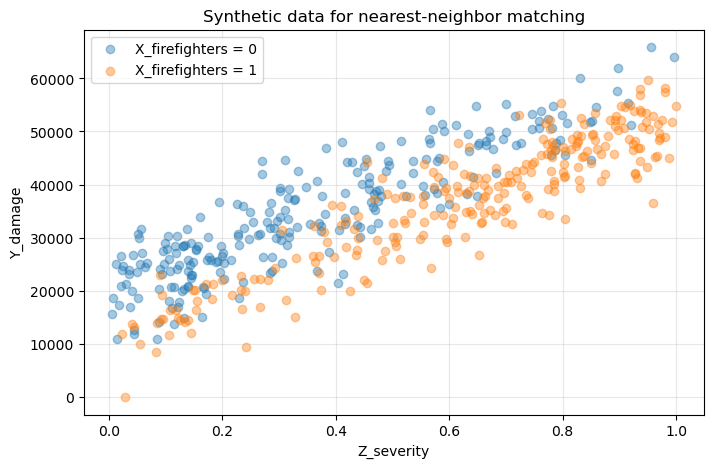

In [14]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Reproducible synthetic data
rng = np.random.default_rng(42)

n = 500
Z_severity = rng.uniform(0, 1, n)

# Treatment assignment depends on severity
p_treat = 1 / (1 + np.exp(-4 * (Z_severity - 0.5)))
X_firefighters = rng.binomial(1, p_treat, size=n)

# Outcome
Y_damage = 20000 + 40000 * Z_severity - 8000 * X_firefighters + rng.normal(0, 5000, n)
Y_damage = np.clip(Y_damage, 0, None)

df = pd.DataFrame({
    "X_firefighters": X_firefighters,
    "Y_damage": Y_damage,
    "Z_severity": Z_severity
})

treated = df[df["X_firefighters"] == 1].copy().reset_index(drop=True)
control = df[df["X_firefighters"] == 0].copy().reset_index(drop=True)

# Nearest-neighbor matching on severity
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["Z_severity"]])
distances, indices = nn.kneighbors(treated[["Z_severity"]])

matched_controls = control.iloc[indices.flatten()].copy().reset_index(drop=True)
#print("Here", indices)
#print("Here 2", matched_controls)

# Effect estimate
treated_mean = treated["Y_damage"].mean()
matched_control_mean = matched_controls["Y_damage"].mean()
effect_hat = treated_mean - matched_control_mean

# More detailed printouts
print("=== Matching setup ===")
print(f"Total observations: {len(df)}")
print(f"Treated units (X_firefighters = 1): {len(treated)}")
print(f"Control units (X_firefighters = 0): {len(control)}")
print()

print("=== Mean severity by group ===")
print(f"Mean Z_severity among treated: {treated['Z_severity'].mean():.4f}")
print(f"Mean Z_severity among controls: {control['Z_severity'].mean():.4f}")
print(f"Mean Z_severity among matched controls: {matched_controls['Z_severity'].mean():.4f}")
print()

print("=== Mean damage by group ===")
print(f"Mean Y_damage among treated: {treated_mean:.2f}")
print(f"Mean Y_damage among matched controls: {matched_control_mean:.2f}")
print(f"Estimated effect (treated - matched controls): {effect_hat:.2f}")
print()

print("=== Matching math ===")
print("For each treated unit i:")
print("  1. Find the control unit j with closest Z_severity")
print("  2. Compute the matched-pair difference: Y_i - Y_j")
print("  3. Average those differences over all treated units")
print()

pair_diffs = treated["Y_damage"].to_numpy() - matched_controls["Y_damage"].to_numpy()
print(f"Average matched-pair difference: {pair_diffs.mean():.2f}")
print(f"Median matched-pair difference: {np.median(pair_diffs):.2f}")
print(f"Std. dev. of matched-pair differences: {pair_diffs.std(ddof=1):.2f}")
print()

print("=== First 10 matched pairs ===")
for k in range(min(10, len(treated))):
    print(
        f"Pair {k+1}: "
        f"Treated(Z={treated.loc[k, 'Z_severity']:.4f}, Y={treated.loc[k, 'Y_damage']:.2f})  "
        f"<->  "
        f"Control(Z={matched_controls.loc[k, 'Z_severity']:.4f}, Y={matched_controls.loc[k, 'Y_damage']:.2f})  "
        f"| Difference = {pair_diffs[k]:.2f}  "
        f"| |ΔZ| = {abs(treated.loc[k, 'Z_severity'] - matched_controls.loc[k, 'Z_severity']):.4f}"
    )

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(control["Z_severity"], control["Y_damage"], alpha=0.4, label="X_firefighters = 0")
plt.scatter(treated["Z_severity"], treated["Y_damage"], alpha=0.4, label="X_firefighters = 1")
plt.xlabel("Z_severity")
plt.ylabel("Y_damage")
plt.title("Synthetic data for nearest-neighbor matching")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()